In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!pip install datasets
!pip install textstat
!pip install bert_score
!pip install evaluate


In [3]:
import pandas as pd


In [4]:
# Define the file paths
file_path_original = '/content/drive/MyDrive/MEDICAL/DATASET/complex_text.txt'
file_path_simple = '/content/drive/MyDrive/MEDICAL/DATASET/simple_text.txt'

In [5]:
# Reading the content of both files, specifying the encoding
with open(file_path_original, 'r', encoding='latin-1') as original_file:  # Try 'latin-1' first
    original_text = original_file.read()

with open(file_path_simple, 'r', encoding='latin-1') as simple_file:  # Try 'latin-1' for consistency
    simple_text = simple_file.read()

In [6]:
# Split the original and simple text into lines to prepare for storing them in a dataframe
original_lines = original_text.splitlines()
simple_lines = simple_text.splitlines()

# Removing empty lines from both texts
original_lines_cleaned = [line for line in original_lines if line.strip() != '']
simple_lines_cleaned = [line for line in simple_lines if line.strip() != '']

In [7]:
# Pad the shorter list (simple_lines_cleaned) with empty strings to match the length of the original_lines_cleaned
while len(simple_lines_cleaned) < len(original_lines_cleaned):
    simple_lines_cleaned.append('')

# Create a dataframe with two columns: 'Original' and 'Simple'
data = {
    "Original": original_lines_cleaned,
    "Simple": simple_lines_cleaned
}

In [8]:
df = pd.DataFrame(data)
df = df.iloc[:-12]
df.head()

,Original,Simple
0,The patient presented with a history of chroni...,The patient came in with worsening COPD sympto...
1,The patient was diagnosed with type 2 diabetes...,The patient was diagnosed with type 2 diabetes...
2,A 45-year-old male presented to the emergency ...,A 45-year-old man came to the emergency room w...
3,"The patient, a 62-year-old female, presented w...",A 62-year-old woman came in with worsening low...
4,"The patient, a 50-year-old male with a history...",A 50-year-old man with a history of high blood...


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 261 entries, 0 to 260
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Original  261 non-null    object
 1   Simple    261 non-null    object
dtypes: object(2)
memory usage: 4.2+ KB


In [10]:
for i in range(5):
  print('Actual :' ,df.iloc[i,0])
  print('-----' * 50)
  print('Simple :', df.iloc[i,1])
  print('-----' * 50)

Actual : The patient presented with a history of chronic obstructive pulmonary disease (COPD) exacerbation, accompanied by increased dyspnea, wheezing, and productive cough. Despite previous treatment with bronchodilators and corticosteroids, the symptoms had worsened over the past week. On examination, the patient had a respiratory rate of 28 breaths per minute, and oxygen saturation was 88% on room air. Auscultation revealed bilateral wheezing and diminished breath sounds. A chest X-ray was ordered to rule out pneumonia, and the patient was started on antibiotics and supplemental oxygen. The decision was made to admit the patient for further observation and management of the acute COPD exacerbation.
----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Simple : The patient came in with wors

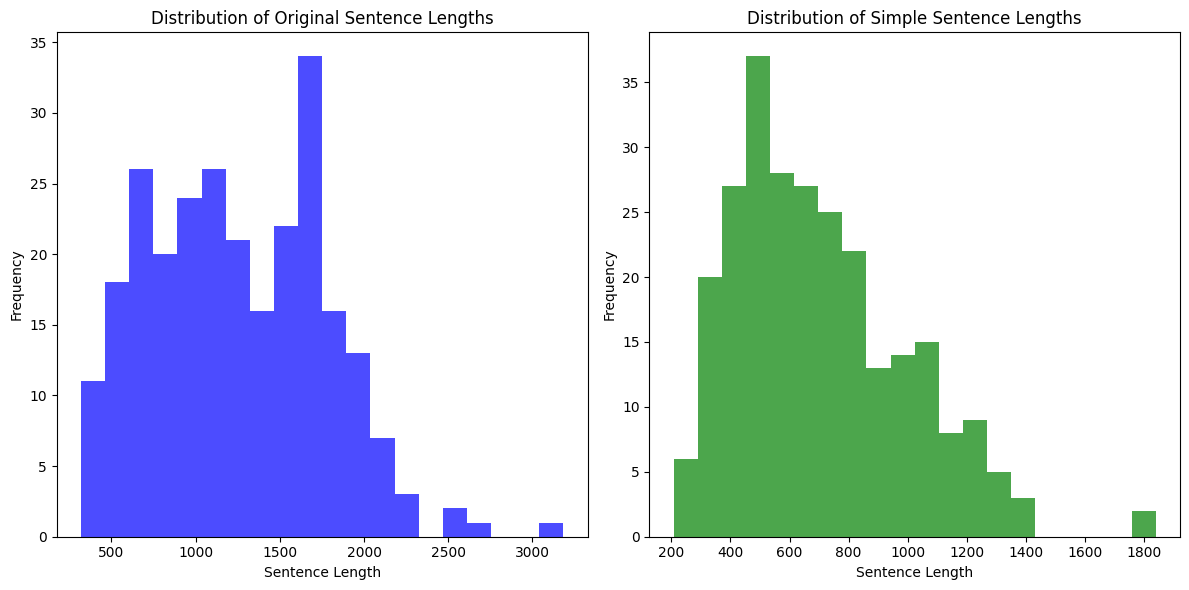

In [11]:

import matplotlib.pyplot as plt

# Calculate the length of each sentence in both columns
df['Original Length'] = df['Original'].apply(len)
df['Simple Length'] = df['Simple'].apply(len)

# Plot the histograms
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.hist(df['Original Length'], bins=20, color='blue', alpha=0.7)
plt.title('Distribution of Original Sentence Lengths')
plt.xlabel('Sentence Length')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
plt.hist(df['Simple Length'], bins=20, color='green', alpha=0.7)
plt.title('Distribution of Simple Sentence Lengths')
plt.xlabel('Sentence Length')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


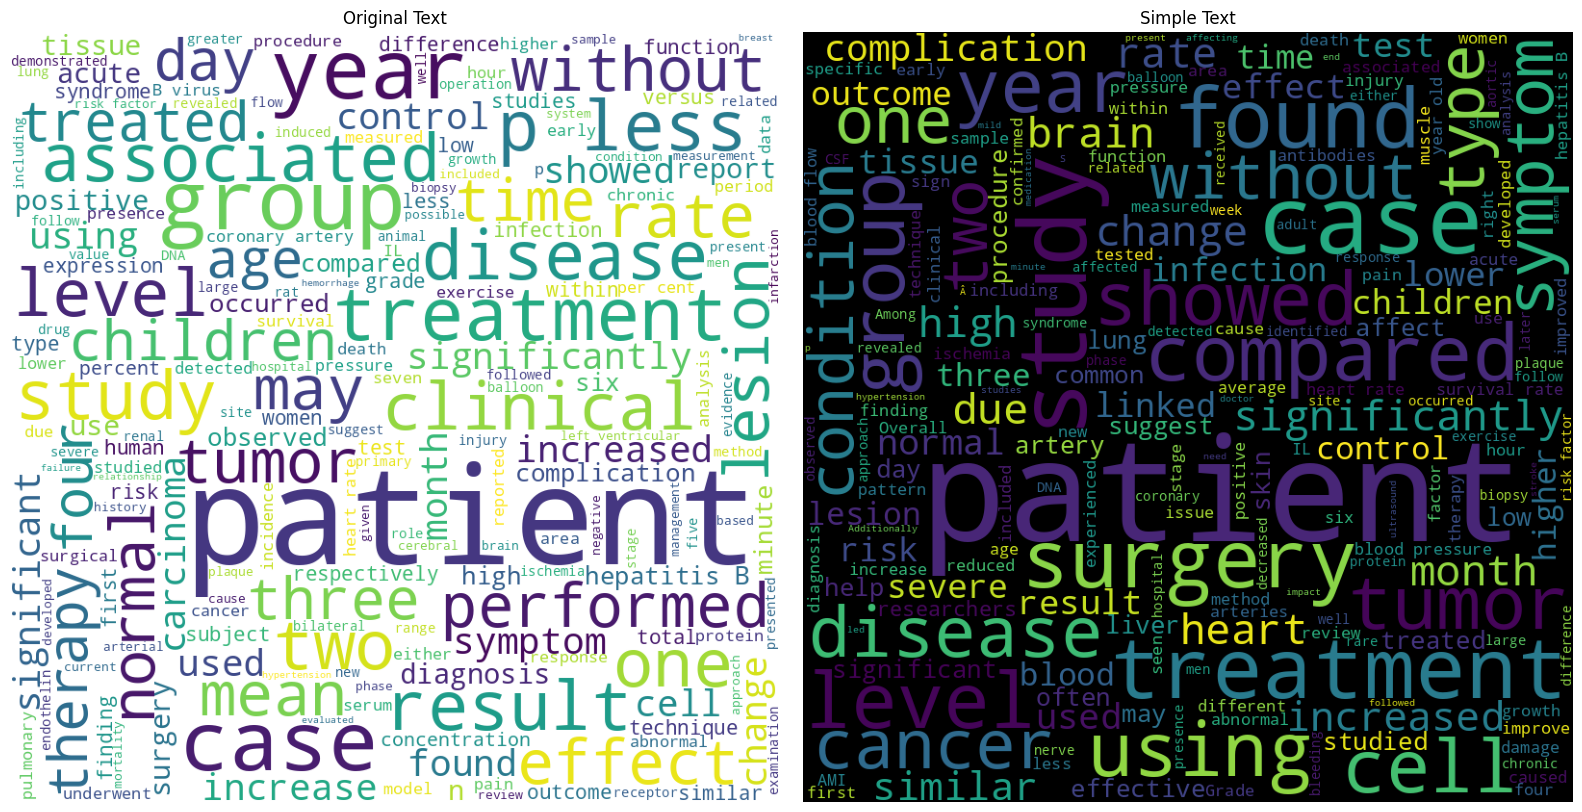

In [12]:

from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

# Create stopwords
stopwords = set(STOPWORDS)

# Create subplots
fig, axs = plt.subplots(1, 2, figsize=(16, 8))

# Plot word cloud for 'Original' column
wordcloud_original = WordCloud(width = 800, height = 800,
                background_color ='white',
                stopwords = stopwords,
                min_font_size = 10).generate(' '.join(df['Original']))

axs[0].imshow(wordcloud_original)
axs[0].axis("off")
axs[0].set_title('Original Text')

# Plot word cloud for 'Simple' column
wordcloud_simple = WordCloud(width = 800, height = 800,
                background_color ='black',
                stopwords = stopwords,
                min_font_size = 10).generate(' '.join(df['Simple']))

axs[1].imshow(wordcloud_simple)
axs[1].axis("off")
axs[1].set_title('Simple Text')

plt.tight_layout()
plt.show()


In [13]:
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag
import pandas as pd
from datasets import Dataset as HFDataset
from transformers import BartTokenizer, BartForConditionalGeneration, DataCollatorForSeq2Seq
from torch.utils.data import DataLoader
import torch


In [14]:
# Download NLTK data
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


True

In [15]:
def preprocess_text(text):
    lemmatizer, stop_words = WordNetLemmatizer(), set(stopwords.words('english'))
    return ' '.join(
        lemmatizer.lemmatize(w, 'a' if t.startswith('J') else 'v' if t.startswith('V') else 'n' if t.startswith('N') else 'r' if t.startswith('R') else 'n')
        for w, t in pos_tag(word_tokenize(text.lower())) if w.isalnum() and w not in stop_words
    )


In [16]:
# Prepare dataset from pandas DataFrame
def prepare_dataset(df):
    df['input_text'] = df['Original'].apply(preprocess_text)
    df['target_text'] = df['Simple'].apply(preprocess_text)
    data = {'input_text': df['input_text'].tolist(), 'target_text': df['target_text'].tolist()}
    return HFDataset.from_dict(data)

In [17]:
# Prepare and preprocess dataset
dataset = prepare_dataset(df)

# T5

In [18]:
import matplotlib.pyplot as plt
!pip install transformers torch sentencepiece

from transformers import T5Tokenizer, T5ForConditionalGeneration

In [19]:
# Load T5 tokenizer and model
tokenizer_t5 = T5Tokenizer.from_pretrained("t5-base")
model_t5 = T5ForConditionalGeneration.from_pretrained("t5-base")

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565
Special tokens have

In [20]:
# Tokenization function for T5 (adjust max_length as needed)
def tokenize_function_t5(examples):
    inputs = tokenizer_t5(
        examples['input_text'],
        max_length=1024,
        truncation=True,
        padding='max_length',
        return_tensors='pt'
    )
    labels = tokenizer_t5(
        examples['target_text'],
        max_length=1024,
        truncation=True,
        padding='max_length',
        return_tensors='pt'
    )
    inputs['labels'] = labels['input_ids']
    return inputs

In [21]:
# Tokenize the dataset using T5 tokenizer
tokenized_dataset_t5 = dataset.map(tokenize_function_t5, batched=True)
tokenized_dataset_t5.set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels'])

# DataLoader for T5
dataloader_t5 = DataLoader(tokenized_dataset_t5, batch_size=1, shuffle=True)

# Move model to device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.cuda.empty_cache()
model_t5.to(device)

# model_t5.to(device)

# Optimizer and scheduler (adjust learning rate as needed)
optimizer_t5 = torch.optim.AdamW(model_t5.parameters(), lr=5e-5)
scheduler_t5 = torch.optim.lr_scheduler.StepLR(optimizer_t5, step_size=1, gamma=0.95)

Map:   0%|          | 0/261 [00:00<?, ? examples/s]

Epoch 1/20, Loss: 1.2337
Epoch 2/20, Loss: 0.4303
Epoch 3/20, Loss: 0.3988
Epoch 4/20, Loss: 0.3733
Epoch 5/20, Loss: 0.3544
Epoch 6/20, Loss: 0.3415
Epoch 7/20, Loss: 0.3255
Epoch 8/20, Loss: 0.3120
Epoch 9/20, Loss: 0.3033
Epoch 10/20, Loss: 0.2943
Epoch 11/20, Loss: 0.2851
Epoch 12/20, Loss: 0.2772
Epoch 13/20, Loss: 0.2696
Epoch 14/20, Loss: 0.2623
Epoch 15/20, Loss: 0.2564
Epoch 16/20, Loss: 0.2503
Epoch 17/20, Loss: 0.2436
Epoch 18/20, Loss: 0.2440
Epoch 19/20, Loss: 0.2343
Epoch 20/20, Loss: 0.2295


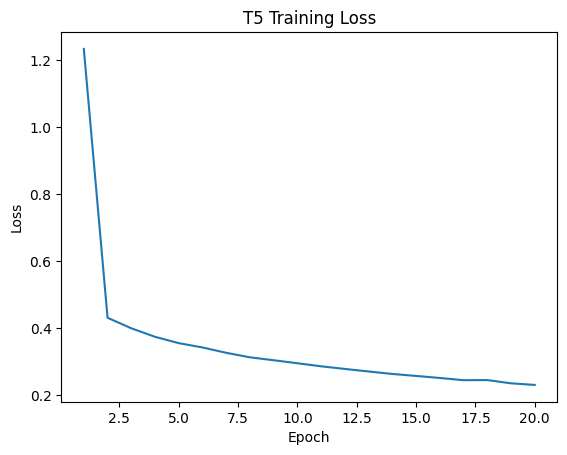

In [22]:


# Training loop for T5
num_epochs = 20  # Adjust as needed
losses_t5 = []
for epoch in range(num_epochs):
    model_t5.train()
    total_loss = 0
    for batch in dataloader_t5:
        optimizer_t5.zero_grad()
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model_t5(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        total_loss += loss.item()

        loss.backward()
        optimizer_t5.step()

    scheduler_t5.step()
    avg_loss = total_loss / len(dataloader_t5)
    losses_t5.append(avg_loss)
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}")

# Plotting the losses for T5
plt.plot(range(1, num_epochs + 1), losses_t5)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('T5 Training Loss')
plt.show()

# # Save the T5 model and tokenizer (adjust paths as needed)
# model_t5.save_pretrained('/content/drive/MyDrive/MEDICAL/Model_res/t5_simplification_model')
# tokenizer_t5.save_pretrained('/content/drive/MyDrive/MEDICAL/Model_res/t5_simplification_model')


In [23]:
from datasets import load_metric


In [24]:
import evaluate

# Load BLEU and COMET metrics
bleu_metric = evaluate.load("bleu", trust_remote_code=True)
nltk.download('punkt')
bert_score_metric = load_metric("bertscore", trust_remote_code=True)
meteor_metric = load_metric('meteor', trust_remote_code=True)

# Import BLEU and COMET
from datasets import load_metric

# Load BLEU and COMET metrics
bleu_metric = load_metric("bleu", trust_remote_code=True)


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
<ipython-input-24-14f30f86f408>:6: FutureWarning: load_metric is deprecated and will be removed in the next major version of datasets. Use 'evaluate.load' instead, from the new library 🤗 Evaluate: https://huggingface.co/docs/evaluate
  bert_score_metric = load_metric("bertscore", trust_remote_code=True)
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [25]:

# Function to generate simplified text using T5
def generate_simplified_text_t5(complex_text):
    model_t5.eval()
    inputs = tokenizer_t5(complex_text, return_tensors='pt', max_length=1024, truncation=True).to(device)
    summary_ids = model_t5.generate(inputs['input_ids'], max_length=1024, num_beams=4, early_stopping=True)
    simplified_text = tokenizer_t5.decode(summary_ids[0], skip_special_tokens=True)
    return simplified_text




In [26]:

# # Sample 10 random rows from the dataframe
# sample_df = df.sample(10)

# for index, row in sample_df.iterrows():
#     complex_text = row['Original']
#     reference_simple_text = row['Simple']

#     # Generate simplified text using T5
#     generated_simple_text_t5 = generate_simplified_text_t5(complex_text)

#     print("--" * 50)
#     print("Original Complex Text:", complex_text)
#     print("--" * 20)
#     print("Original Simple Text:", reference_simple_text)
#     print("--" * 20)
#     print("Generated Simple Text (T5):", generated_simple_text_t5)
#     print("--" * 50)


In [27]:
from datasets import load_metric
import nltk
from nltk.tokenize import sent_tokenize, word_tokenize
from textstat import flesch_kincaid_grade

In [28]:
# Evaluation Functions
def evaluate_readability(text):
    fkgl = flesch_kincaid_grade(text)
    return fkgl

from nltk.translate.bleu_score import sentence_bleu

# Ensure you have downloaded the necessary NLTK data files
nltk.download('punkt')

def evaluate_metrics(pred_text, ref_text):
    # Readability score
    fkgl = evaluate_readability(pred_text)

    # BERTScore
    bert_score = bert_score_metric.compute(predictions=[pred_text], references=[ref_text], lang="en")

    # METEOR score
    meteor = meteor_metric.compute(predictions=[pred_text], references=[ref_text])['meteor']

    # BLEU score
    reference_tokens = nltk.word_tokenize(ref_text)
    prediction_tokens = nltk.word_tokenize(pred_text)
    bleu = sentence_bleu([reference_tokens], prediction_tokens)

    return fkgl, bert_score, meteor, bleu


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [29]:
# Define the file paths for your evaluation data
eval_file_path_original = '/content/drive/MyDrive/MEDICAL/DATASET/original_text.txt'
eval_file_path_simple = '/content/drive/MyDrive/MEDICAL/DATASET/simplified_text.txt'


In [30]:
# Load the evaluation data
with open(eval_file_path_original, 'r', encoding='latin-1') as original_file:
    eval_original_text = original_file.read()

with open(eval_file_path_simple, 'r', encoding='latin-1') as simple_file:
    eval_simple_text = simple_file.read()


In [31]:

# Split the texts into lines
eval_original_lines = eval_original_text.splitlines()
eval_simple_lines = eval_simple_text.splitlines()

# Removing empty lines from both texts
eval_original_lines = [line for line in eval_original_lines if line.strip() != '']
eval_simple_lines = [line for line in eval_simple_lines if line.strip() != '']



# Preprocess the evaluation data (similar to training data)
eval_original_lines = [preprocess_text(line) for line in eval_original_lines]
eval_simple_lines = [preprocess_text(line) for line in eval_simple_lines]

In [32]:

# Initialize lists to store metric values
fkgl_scores = []
bert_scores = []
meteor_scores = []
bleu_scores = []

# Evaluate and store metrics for each pair of sentences
for original, simple in zip(eval_original_lines, eval_simple_lines):
    simplified_text = generate_simplified_text_t5(original)

    fkgl, bert_score, meteor, bleu = evaluate_metrics(simplified_text, simple)

    fkgl_scores.append(fkgl)
    bert_scores.append(bert_score['f1'][0])
    meteor_scores.append(meteor)
    bleu_scores.append(bleu)

# Calculate and print average metrics
avg_fkgl = sum(fkgl_scores) / len(fkgl_scores)
avg_bert_score = sum(bert_scores) / len(bert_scores)
avg_meteor = sum(meteor_scores) / len(meteor_scores)
avg_bleu = sum(bleu_scores) / len(bleu_scores)




Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.10/dist-packages/nltk/translate/bleu_score.py:552: UserWarning: 
The hypothesis contains 0 counts of 3-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
/usr/local/lib/python3.10/dist-packages/nltk/translate/bleu_score.py:552: UserWarning: 
The hypothesis contains 0 counts of 4-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)


In [33]:
print("\nAverage Metrics:")
print("-" * 20)
print("Average Flesch-Kincaid Grade Level:", avg_fkgl)
print("Average BERTScore:", avg_bert_score)
print("Average METEOR Score:", avg_meteor)
print("Average BLEU Score:", avg_bleu)


Average Metrics:
--------------------
Average Flesch-Kincaid Grade Level: 28.229999999999997
Average BERTScore: 0.884139895439148
Average METEOR Score: 0.3771600869801205
Average BLEU Score: 0.09928239603061817


In [34]:

import numpy as np
num_samples = 2
sample_indices = np.random.choice(len(eval_original_lines), num_samples, replace=False)

for i in sample_indices:
    original_text = eval_original_lines[i]
    reference_simple_text = eval_simple_lines[i]
    generated_simple_text = generate_simplified_text_t5(original_text)

    print("-" * 50)
    print(f"Sample {i+1}")
    print("-" * 50)
    print("Original Complex Text:", original_text)
    print("-" * 20)
    print("Reference Simple Text:", reference_simple_text)
    print("-" * 20)
    print("Generated Simple Text:", generated_simple_text)
    print("-" * 50)


--------------------------------------------------
Sample 3
--------------------------------------------------
Original Complex Text: male present emergency department chest pain radiate left arm jaw along shortness breath diaphoresis electrocardiogram ecg perform reveal elevation anterior lead consistent acute myocardial infarction patient immediately take catheterization laboratory percutaneous coronary intervention pci significant blockage left anterior descend artery identify successfully treat stent placement patient transfer intensive care unit monitoring recovery
--------------------
Reference Simple Text: man come emergency room sudden chest pain spread left arm jaw along trouble breathing sweating ecg do show sign heart attack patient quickly take lab procedure open blocked artery stent place keep artery open move icu recovery monitoring
--------------------
Generated Simple Text: male present emergency room chest pain radiate left arm jaw along shortness breath diaphoresis el